Cognitive Decline Risk Prediction: A Neural Network Approach with Vectorized Implementation

Data and statistical analysis

Step 1: Importing the required libraries

In [2]:
# importing the libraries
# importing the csv
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


Step 2: Load the dataset and initial exploration

In [3]:
data = pd.read_csv("datasets/enhanced_anxiety_dataset.csv")

# basic dataset info

print("Dataset shape:", data.shape)
print("\nFirst 5 rows:")
print(data.head())
print("\nColumn Names:")
print(data.columns.tolist())
print("\nData Types:")
print(data.dtypes)


Dataset shape: (11000, 19)

First 5 rows:
   Age  Gender Occupation  Sleep Hours  Physical Activity (hrs/week)  \
0   29  Female     Artist          6.0                           2.7   
1   46   Other      Nurse          6.2                           5.7   
2   64    Male      Other          5.0                           3.7   
3   20  Female  Scientist          5.8                           2.8   
4   49  Female      Other          8.2                           2.3   

   Caffeine Intake (mg/day)  Alcohol Consumption (drinks/week) Smoking  \
0                       181                                 10     Yes   
1                       200                                  8     Yes   
2                       117                                  4      No   
3                       360                                  6     Yes   
4                       247                                  4     Yes   

  Family History of Anxiety  Stress Level (1-10)  Heart Rate (bpm)  \
0         

Descriptive statistics

In [4]:
# Basic descriptive statistics for numerical variables
desc_stats = data.describe(include=[np.number])
print("Descriptive Statistics (Numerical Variables):")
print(desc_stats)
print("\n" + "="*50)



Descriptive Statistics (Numerical Variables):
                Age   Sleep Hours  Physical Activity (hrs/week)  \
count  11000.000000  11000.000000                  11000.000000   
mean      40.241727      6.650691                      2.942136   
std       13.236140      1.227509                      1.827825   
min       18.000000      2.300000                      0.000000   
25%       29.000000      5.900000                      1.500000   
50%       40.000000      6.700000                      2.800000   
75%       51.000000      7.500000                      4.200000   
max       64.000000     11.300000                     10.100000   

       Caffeine Intake (mg/day)  Alcohol Consumption (drinks/week)  \
count              11000.000000                       11000.000000   
mean                 286.090000                           9.701636   
std                  144.813157                           5.689713   
min                    0.000000                           0.000000   


In [5]:
# For categorical variables
cat_stats = data.describe(include=['object'])
print("Descriptive Statistics (Categorical Variables):")
print(cat_stats)

Descriptive Statistics (Categorical Variables):
        Gender Occupation Smoking Family History of Anxiety Dizziness  \
count    11000      11000   11000                     11000     11000   
unique       3         13       2                         2         2   
top     Female   Musician     Yes                       Yes       Yes   
freq      3730        892    5779                      5847      5672   

       Medication Recent Major Life Event  
count       11000                   11000  
unique          2                       2  
top           Yes                     Yes  
freq         5666                    5623  


Missing values analysis

In [6]:
data.isnull().sum()

Age                                  0
Gender                               0
Occupation                           0
Sleep Hours                          0
Physical Activity (hrs/week)         0
Caffeine Intake (mg/day)             0
Alcohol Consumption (drinks/week)    0
Smoking                              0
Family History of Anxiety            0
Stress Level (1-10)                  0
Heart Rate (bpm)                     0
Breathing Rate (breaths/min)         0
Sweating Level (1-5)                 0
Dizziness                            0
Medication                           0
Therapy Sessions (per month)         0
Recent Major Life Event              0
Diet Quality (1-10)                  0
Anxiety Level (1-10)                 0
dtype: int64

Missing Value Analysis:
Empty DataFrame
Columns: [Missing Values, Percentage]
Index: []


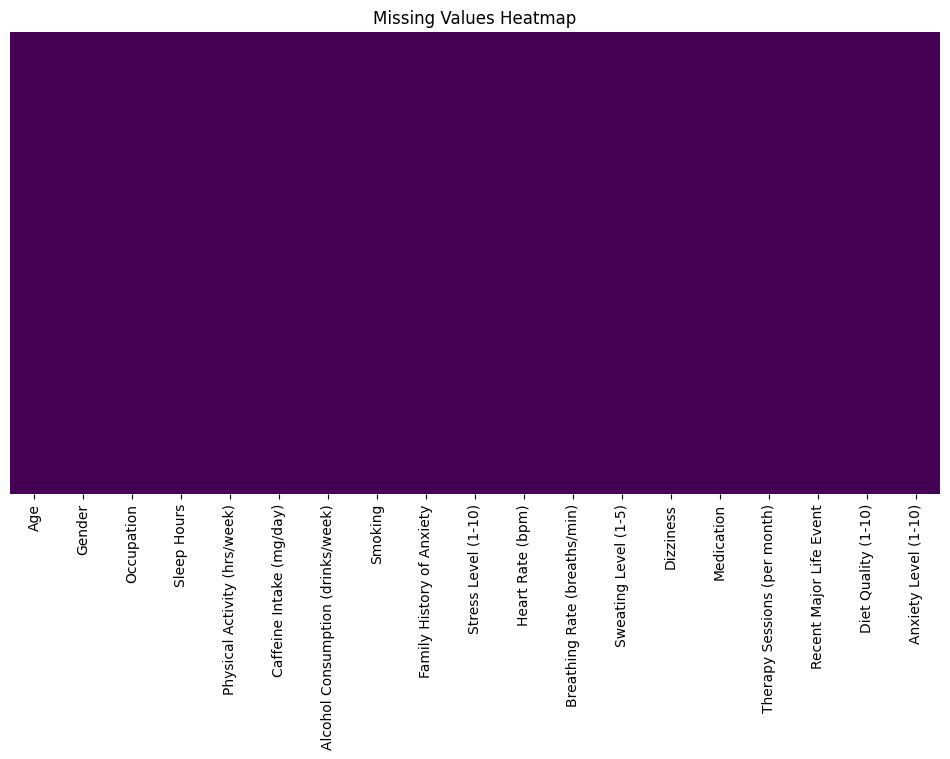

In [7]:
# Missing values summary
missing_data = pd.DataFrame({
    'Missing Values': data.isnull().sum(),
    'Percentage': (data.isnull().sum() / len(data)) * 100
})
missing_data = missing_data[missing_data['Missing Values'] > 0]
missing_data = missing_data.sort_values('Percentage', ascending=False)

print("Missing Value Analysis:")
print(missing_data)

# Visualize missing values
plt.figure(figsize=(12, 6))
sns.heatmap(data.isnull(), cbar=False, cmap='viridis', yticklabels=False)
plt.title('Missing Values Heatmap')
plt.show()

CORRELATION ANALYSIS

/tmp/ipykernel_2134/860027725.py:15: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .replace({'Yes': 1, 'No': 0})


Number of numeric columns: 18
Index(['Age', 'Gender', 'Sleep Hours', 'Physical Activity (hrs/week)',
       'Caffeine Intake (mg/day)', 'Alcohol Consumption (drinks/week)',
       'Smoking', 'Family History of Anxiety', 'Stress Level (1-10)',
       'Heart Rate (bpm)', 'Breathing Rate (breaths/min)',
       'Sweating Level (1-5)', 'Dizziness', 'Medication',
       'Therapy Sessions (per month)', 'Recent Major Life Event',
       'Diet Quality (1-10)', 'Anxiety Level (1-10)'],
      dtype='object')


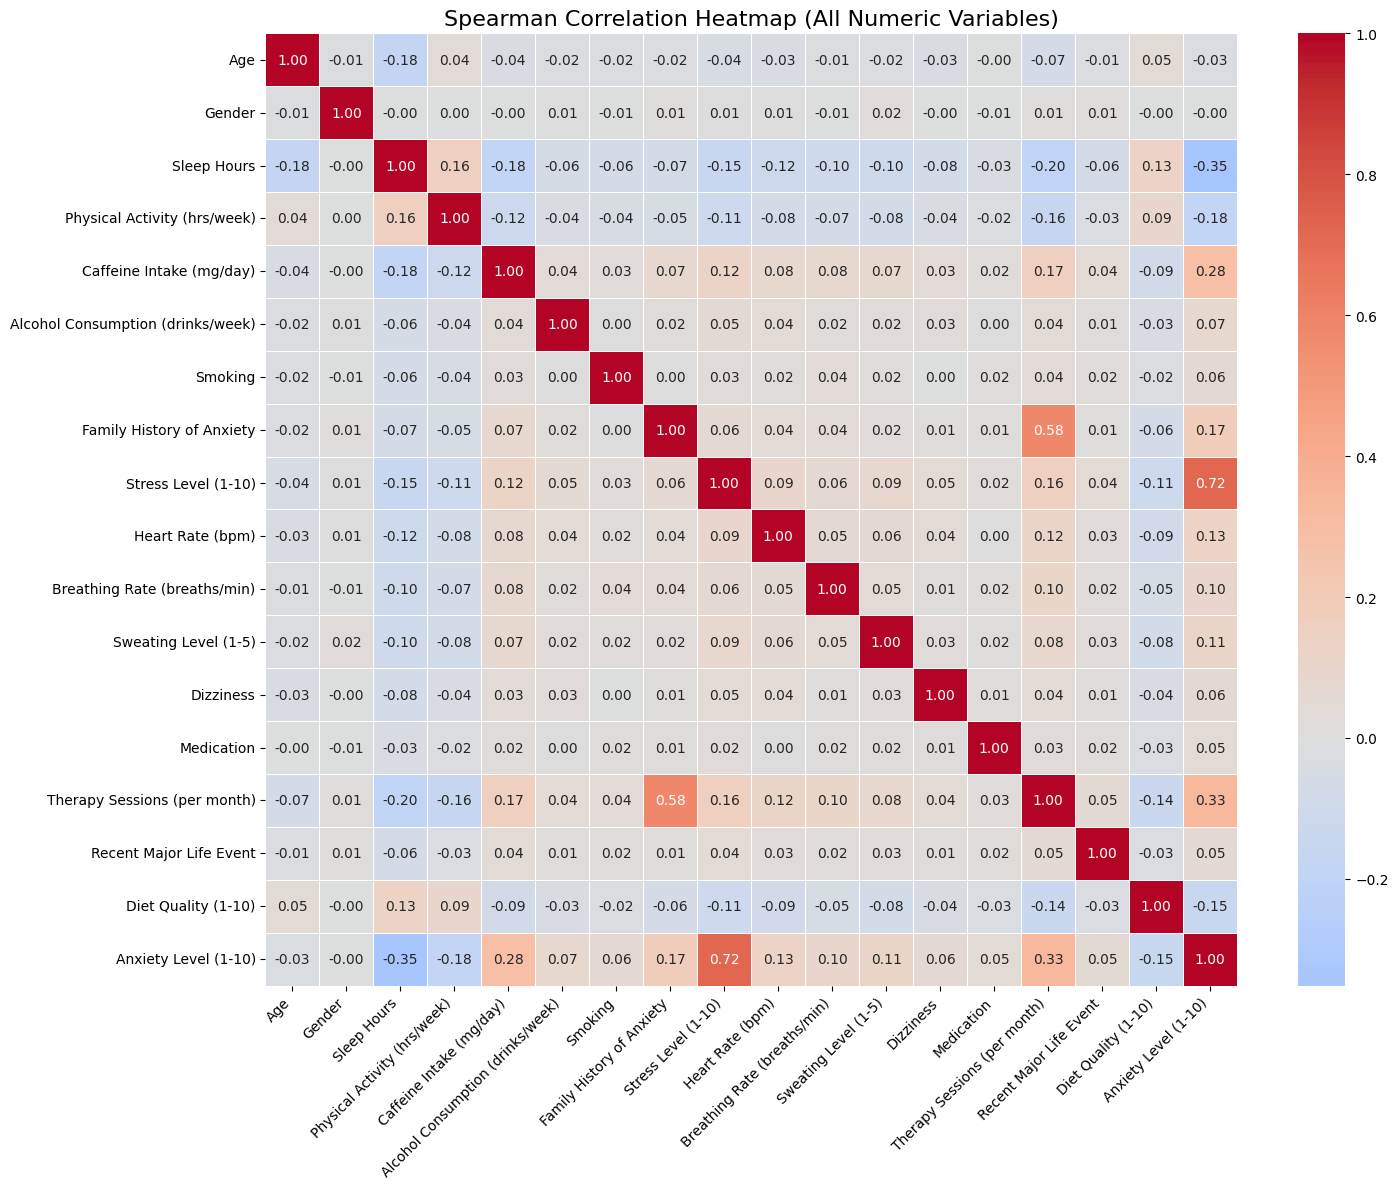

In [8]:
# 1️ Convert Gender to binary (DO NOT drop column)
data['Gender'] = data['Gender'].map({'Male': 1, 'Female': 0})

# 2️ Convert Yes/No columns to 1/0 (DO NOT overwrite data)
yes_no_cols = [
    'Smoking',
    'Family History of Anxiety',
    'Dizziness',
    'Medication',
    'Recent Major Life Event'
]

data[yes_no_cols] = (
    data[yes_no_cols]
    .replace({'Yes': 1, 'No': 0})
    .infer_objects(copy=False)
)

# 3️ Select ALL numeric columns (should be 18)
numeric_data = data.select_dtypes(include=['int64', 'float64'])

print(f"Number of numeric columns: {numeric_data.shape[1]}")
print(numeric_data.columns)

# 4️ Compute Spearman correlation
corr_matrix = numeric_data.corr(method='spearman')

# 5️ Plot heatmap
plt.figure(figsize=(15, 12))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)

plt.title("Spearman Correlation Heatmap (All Numeric Variables)", fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

Highly correlated columns:
['Sleep Hours', 'Caffeine Intake (mg/day)', 'Stress Level (1-10)', 'Therapy Sessions (per month)', 'Anxiety Level (1-10)']


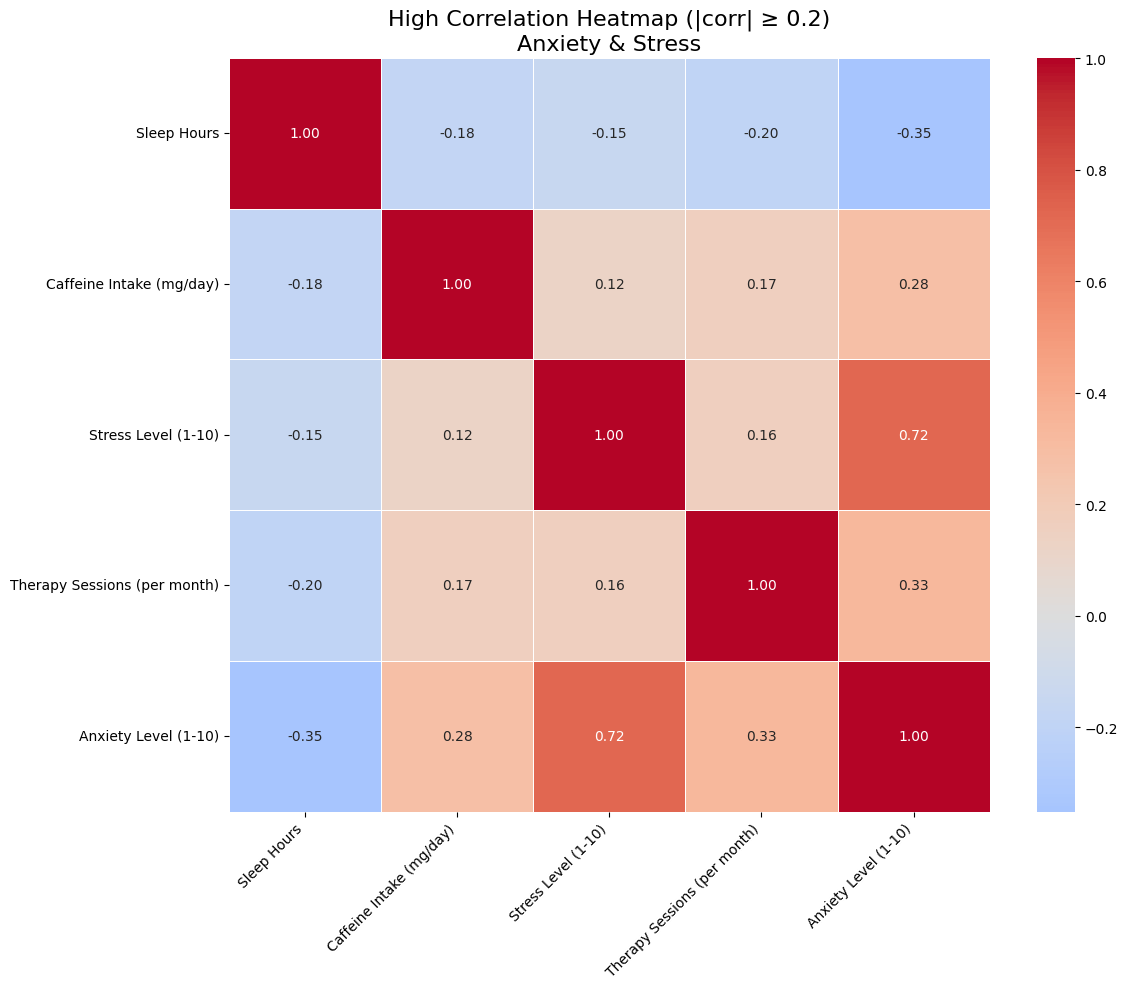

In [ ]:
# Select numeric columns
numeric_data = data.select_dtypes(include=['int64', 'float64'])

# Compute Spearman correlation
corr_matrix = numeric_data.corr(method='spearman')

# Set correlation threshold
threshold = 0.3

# Find columns highly correlated with Anxiety or Stress
target_cols = ['Anxiety Level (1-10)', 'Stress Level (1-10)']

high_corr_cols = corr_matrix[
    target_cols
].abs().max(axis=1)

high_corr_cols = high_corr_cols[high_corr_cols >= threshold].index.tolist()

print("Highly correlated columns:")
print(high_corr_cols)

# Filter correlation matrix
filtered_corr = corr_matrix.loc[high_corr_cols, high_corr_cols]

# Plot heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(
    filtered_corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)

plt.title(
    f"High Correlation Heatmap (|corr| ≥ {threshold})\nAnxiety & Stress",
    fontsize=16
)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()